<a href="https://colab.research.google.com/github/MacKumachin/Clifford-FBSM-SignalControl/blob/main/SVAR%E6%8E%A8%E5%AE%9A.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [31]:
# Colabに標準搭載されていますが、念のためデータ取得用ライブラリをインポート
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pandas_datareader.data as web
import datetime
from statsmodels.tsa.stattools import adfuller

# グラフのスタイル設定
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller

# グラフのスタイル設定
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

# ---------------------------------------------------------
# 1. データの読み込みとクレンジング
# ---------------------------------------------------------

# ① マクロ変数データの読み込み（これは英語ベースなのでそのまま）
df_macro = pd.read_csv("macro_control_variables.csv")
df_macro['Date'] = pd.to_datetime(df_macro['Unnamed: 0']).dt.to_period('M')
df_macro = df_macro.drop(columns=['Unnamed: 0'])

# ② 短観インフレ期待（企業の物価見通し）の読み込み【修正ポイント：encoding='cp932'】
df_tankan = pd.read_csv("CO'TK99F0000201HCQ00000.csv", encoding='cp932')
df_tankan = df_tankan.drop(0) # 1行目の「系列名称」を削除
df_tankan = df_tankan.rename(columns={'データコード': 'Date', "CO'TK99F0000201HCQ00000": 'Expectation'})
df_tankan['Date'] = pd.to_datetime(df_tankan['Date']).dt.to_period('M')
df_tankan['Expectation'] = pd.to_numeric(df_tankan['Expectation'], errors='coerce')

# 日銀のインフレ目標（2%）との乖離（ギャップ）を計算
df_tankan['Expectation_Gap'] = df_tankan['Expectation'] - 2.0

# ③ 日銀国債保有残高（介入コスト代理変数）の読み込み【修正ポイント：encoding='cp932'】
df_boj = pd.read_csv("BS01'MABJMA5-1.csv", encoding='cp932')
df_boj = df_boj.drop(0) # 1行目の「系列名称」を削除
df_boj = df_boj.rename(columns={'データコード': 'Date', "BS01'MABJMA5": 'BOJ_JGB_Holdings'})
df_boj['Date'] = pd.to_datetime(df_boj['Date']).dt.to_period('M')
df_boj['BOJ_JGB_Holdings'] = pd.to_numeric(df_boj['BOJ_JGB_Holdings'], errors='coerce')

# ---------------------------------------------------------
# 2. データの結合とSVAR向けの前処理（階差・対数変換）
# ---------------------------------------------------------

# 全てのデータを「Date（月）」をキーにして結合
df = df_macro.merge(df_tankan, on='Date', how='inner')
df = df.merge(df_boj, on='Date', how='inner')

# Statsmodelsでの扱いを良くするために、Period型からTimestamp型に戻してインデックスに設定
df['Date'] = df['Date'].dt.to_timestamp()
df = df.set_index('Date')

# 欠損値の除外
df = df.dropna()

print("【結合直後のデータ（先頭5行）】")
display(df.head())

# 前処理済みデータを格納するデータフレーム
df_processed = pd.DataFrame(index=df.index)

# 変数の変換
df_processed['d_ln_BOJ_JGB'] = np.log(df['BOJ_JGB_Holdings']).diff()
df_processed['d_Expectation_Gap'] = df['Expectation_Gap'].diff()
df_processed['d_US_10Y'] = df['US_10Y_Yield'].diff()
df_processed['d_Commodity'] = df['Commodity_Proxy'].diff()

# 階差取得によって発生した先頭行の欠損値(NaN)を削除
df_processed = df_processed.dropna()

print("\n【SVAR推定用の前処理後データ（先頭5行）】")
display(df_processed.head())

# ---------------------------------------------------------
# 3. 定常性の確認（ADF検定）
# ---------------------------------------------------------
print("\n【ADF検定結果（p値が0.05未満なら定常過程とみなせる）】")
for col in df_processed.columns:
    result = adfuller(df_processed[col])
    print(f"{col}: p-value = {result[1]:.4f}")

【結合直後のデータ（先頭5行）】


/tmp/ipykernel_575/4169903507.py:23: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_tankan['Date'] = pd.to_datetime(df_tankan['Date']).dt.to_period('M')
/tmp/ipykernel_575/4169903507.py:33: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_boj['Date'] = pd.to_datetime(df_boj['Date']).dt.to_period('M')


,US_10Y_Yield,Commodity_Proxy,USD_JPY,Expectation,Expectation_Gap,BOJ_JGB_Holdings
Date,,,,,,
2016-01-01,1.94,1116.400024,118.930000,0.3,-1.7,3380763.0
2016-02-01,1.74,1233.900024,113.660004,0.3,-1.7,3453627.0
2016-03-01,1.78,1234.199951,112.365997,0.3,-1.7,3491955.0
2016-04-01,1.83,1289.199951,108.075996,0.2,-1.8,3590664.0
2016-05-01,1.84,1214.800049,110.841003,0.2,-1.8,3705146.0



【SVAR推定用の前処理後データ（先頭5行）】


,d_ln_BOJ_JGB,d_Expectation_Gap,d_US_10Y,d_Commodity
Date,,,,
2016-02-01,0.021324,0.0,-0.20,117.500000
2016-03-01,0.011037,0.0,0.04,0.299927
2016-04-01,0.027875,-0.1,0.05,55.000000
2016-05-01,0.031386,0.0,0.01,-74.399902
2016-06-01,0.015712,0.0,-0.35,103.599976



【ADF検定結果（p値が0.05未満なら定常過程とみなせる）】
d_ln_BOJ_JGB: p-value = 0.1385
d_Expectation_Gap: p-value = 0.0871
d_US_10Y: p-value = 0.0000
d_Commodity: p-value = 0.0000


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


【VARモデルの最適ラグ数選択】

=> 選択された最適ラグ数: 6ヶ月

【SVARモデルの推定】


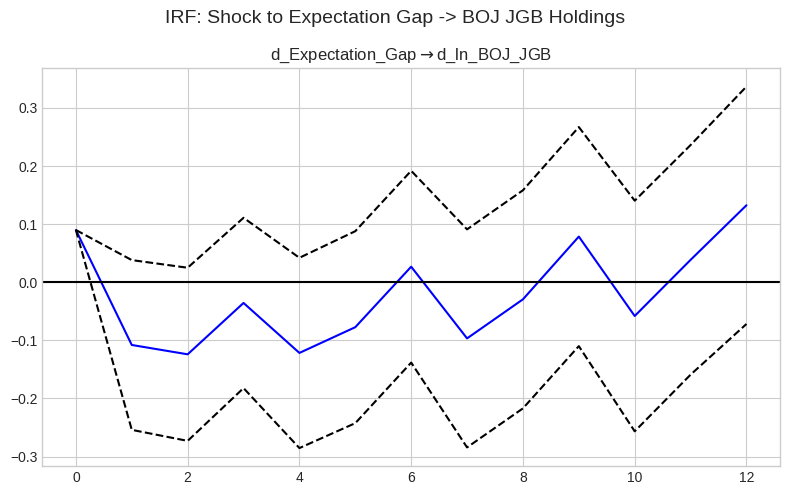

In [33]:
import statsmodels.api as sm
from statsmodels.tsa.api import VAR, SVAR
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# ステップ3: データの標準化と最適ラグ数の選択
# ---------------------------------------------------------
data_svar_raw = df_processed[['d_Commodity', 'd_US_10Y', 'd_Expectation_Gap', 'd_ln_BOJ_JGB']]

# 標準化（スケールの違いによる最適化エラー防止）
data_svar = (data_svar_raw - data_svar_raw.mean()) / data_svar_raw.std()

print("【VARモデルの最適ラグ数選択】")
model_var = VAR(data_svar)
lag_order_results = model_var.select_order(maxlags=6)

# AICが最小となるラグ数を取得（最低ラグ1を確保）
optimal_lag = max(1, lag_order_results.aic)
print(f"\n=> 選択された最適ラグ数: {optimal_lag}ヶ月")

# ---------------------------------------------------------
# ステップ4: SVARの構造制約（A行列）の定義
# ---------------------------------------------------------
# 【完全解決版】すべてを「文字列」で定義することで、型エラーも
# statsmodelsの仕様（'E'が必須）も両方クリアします！
A_matrix = np.array([
    ['1', '0', '0', '0'],
    ['E', '1', '0', '0'],
    ['E', 'E', '1', '0'],
    ['E', 'E', 'E', '1']
])

# ---------------------------------------------------------
# ステップ5: SVARモデルの推定とインパルス応答関数（IRF）
# ---------------------------------------------------------
print("\n【SVARモデルの推定】")
svar_model = SVAR(data_svar, svar_type='A', A=A_matrix)
svar_results = svar_model.fit(maxlags=optimal_lag, maxiter=2000)

# インパルス応答関数（各変数へのショックがどう波及するかを12ヶ月先まで計算）
irf = svar_results.irf(periods=12)

# 松久論文の関心事である「インフレ期待ギャップのショック」が
# 「日銀の介入コスト（国債保有増）」にどう影響するかをプロット
fig = irf.plot(impulse='d_Expectation_Gap', response='d_ln_BOJ_JGB', figsize=(8, 5))
fig.suptitle("IRF: Shock to Expectation Gap -> BOJ JGB Holdings", fontsize=14) # タイトルはここで追加
plt.tight_layout()
plt.show()

<>:103: SyntaxWarning: invalid escape sequence '\D'
<>:103: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_575/4022235797.py:103: SyntaxWarning: invalid escape sequence '\D'
  axes[0].set_ylabel('Cumulative Growth of Intervention Cost ($\Delta_h \ln C_{t+h}$)')


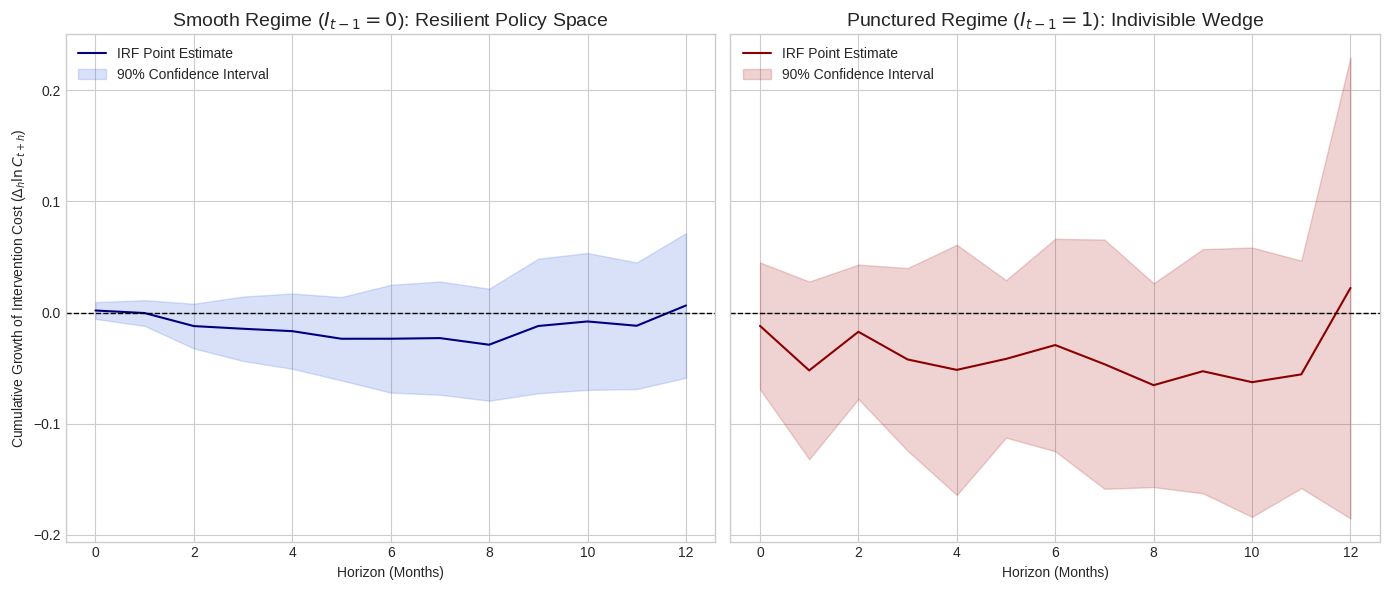

In [34]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. 直交化ショック（Reduced-form Epistemic Shock）の抽出
# 論文の式(6.1)および(6.2)の再現
# ---------------------------------------------------------
df_lp = df.copy() # 前のステップで作った大元の結合データ df を使います

# 対数介入コスト（国債保有残高）
df_lp['ln_BOJ_JGB'] = np.log(df_lp['BOJ_JGB_Holdings'])

# 変数の階差
df_lp['d_Expectation_Gap'] = df_lp['Expectation_Gap'].diff()
df_lp['d_US_10Y'] = df_lp['US_10Y_Yield'].diff()
df_lp['d_Commodity'] = df_lp['Commodity_Proxy'].diff()
df_lp = df_lp.dropna()

# インフレ期待ギャップの変動を、米金利と商品価格で回帰して「純粋な期待のズレ（残差）」を取り出す
X_orth = sm.add_constant(df_lp[['d_US_10Y', 'd_Commodity']])
y_orth = df_lp['d_Expectation_Gap']
orth_model = sm.OLS(y_orth, X_orth).fit()

# これが論文で言う「Shock_t」です
df_lp['Shock'] = orth_model.resid

# ---------------------------------------------------------
# 2. レジーム（状態）の判定
# 論文の式(6.3)の再現：市場トポロジー的ストレス（TI_market）の代理指標
# ---------------------------------------------------------
# 本来は複雑な市場機能低下指標等を合成しますが、ここではマクロ的ストレスの
# 代理として「USD/JPY（為替の圧力）」の高さをストレス指標として用います。
stress_proxy = df_lp['USD_JPY']
threshold = stress_proxy.quantile(0.80) # 80パーセンタイルの閾値

# t-1期のストレスが80%閾値以上なら I_{t-1} = 1 （高ストレス＝Punctured Regime）
df_lp['I_t_minus_1'] = (stress_proxy.shift(1) >= threshold).astype(float)
df_lp['Shock_lag1'] = df_lp['Shock'].shift(1) # コントロール変数用

# ---------------------------------------------------------
# 3. ローカル・プロジェクションの実行（ホライズン h=0 から 12 まで）
# 論文の式(6.4)および(6.5)の再現
# ---------------------------------------------------------
H = 12
res_smooth = {'h': [], 'coef': [], 'ci_lower': [], 'ci_upper': []}
res_punctured = {'h': [], 'coef': [], 'ci_lower': [], 'ci_upper': []}

for h in range(H + 1):
    # 従属変数: Δh ln C_{t+h} = ln C_{t+h} - ln C_{t-1}
    target_col = f'd_ln_C_forward_{h}'
    df_lp[target_col] = df_lp['ln_BOJ_JGB'].shift(-h) - df_lp['ln_BOJ_JGB'].shift(1)

    # 回帰用のデータフレーム（欠損値を除外）
    df_reg = df_lp[['Shock', 'I_t_minus_1', 'Shock_lag1', target_col]].dropna()

    if len(df_reg) > 20: # 自由度の確保
        # 状態依存のショック変数を作成
        # 平時（I_{t-1} = 0）のショック
        df_reg['Shock_Smooth'] = df_reg['Shock'] * (1 - df_reg['I_t_minus_1'])
        # 高ストレス時（I_{t-1} = 1）のショック
        df_reg['Shock_Punctured'] = df_reg['Shock'] * df_reg['I_t_minus_1']

        # 独立変数（定数項 + 状態別ショック + 状態ダミー + ラグショック）
        X = df_reg[['Shock_Smooth', 'Shock_Punctured', 'I_t_minus_1', 'Shock_lag1']]
        X = sm.add_constant(X)
        y = df_reg[target_col]

        # HAC（Newey-West）自己相関・不均一分散頑健標準誤差を用いて回帰
        lp_model = sm.OLS(y, X).fit(cov_type='HAC', cov_kwds={'maxlags': h + 1})

        # 90%信頼区間（1.645 * SE）を計算して保存
        # --- Smooth Regime (平時) ---
        res_smooth['h'].append(h)
        coef_s = lp_model.params['Shock_Smooth']
        se_s = lp_model.bse['Shock_Smooth']
        res_smooth['coef'].append(coef_s)
        res_smooth['ci_lower'].append(coef_s - 1.645 * se_s)
        res_smooth['ci_upper'].append(coef_s + 1.645 * se_s)

        # --- Punctured Regime (限界時) ---
        res_punctured['h'].append(h)
        coef_p = lp_model.params['Shock_Punctured']
        se_p = lp_model.bse['Shock_Punctured']
        res_punctured['coef'].append(coef_p)
        res_punctured['ci_lower'].append(coef_p - 1.645 * se_p)
        res_punctured['ci_upper'].append(coef_p + 1.645 * se_p)

# ---------------------------------------------------------
# 4. 結果のプロット（論文 Figure 3 の再現）
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Smooth Regimeのプロット
axes[0].plot(res_smooth['h'], res_smooth['coef'], color='navy', label='IRF Point Estimate')
axes[0].fill_between(res_smooth['h'], res_smooth['ci_lower'], res_smooth['ci_upper'],
                     color='royalblue', alpha=0.2, label='90% Confidence Interval')
axes[0].axhline(0, color='black', linestyle='--', linewidth=1)
axes[0].set_title('Smooth Regime ($I_{t-1}=0$): Resilient Policy Space', fontsize=14)
axes[0].set_xlabel('Horizon (Months)')
axes[0].set_ylabel('Cumulative Growth of Intervention Cost ($\Delta_h \ln C_{t+h}$)')
axes[0].legend(loc='upper left')

# Punctured Regimeのプロット
axes[1].plot(res_punctured['h'], res_punctured['coef'], color='darkred', label='IRF Point Estimate')
axes[1].fill_between(res_punctured['h'], res_punctured['ci_lower'], res_punctured['ci_upper'],
                     color='firebrick', alpha=0.2, label='90% Confidence Interval')
axes[1].axhline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_title('Punctured Regime ($I_{t-1}=1$): Indivisible Wedge', fontsize=14)
axes[1].set_xlabel('Horizon (Months)')
axes[1].legend(loc='upper left')

plt.tight_layout()
plt.show()

【検証1：閾値のストレステスト (Horizon h=6ヶ月後)】


,閾値 (Threshold),限界時 (Punctured Regime) の係数,平時 (Smooth Regime) の係数
0,上位 30% (70th Percentile),-0.0701 (SE: 0.0429),-0.0295 (SE: 0.0297)
1,上位 25% (75th Percentile),-0.0429 (SE: 0.0810),-0.0276 (SE: 0.0297)
2,上位 19% (80th Percentile),-0.0292 (SE: 0.0581),-0.0235 (SE: 0.0295)
3,上位 15% (85th Percentile),-0.0660 (SE: 0.0400),-0.0214 (SE: 0.0295)
4,上位 9% (90th Percentile),0.1011 (SE: 0.0539),-0.0200 (SE: 0.0301)



【検証2：JGB買い入れフロー（純増額）ベースでの検証】


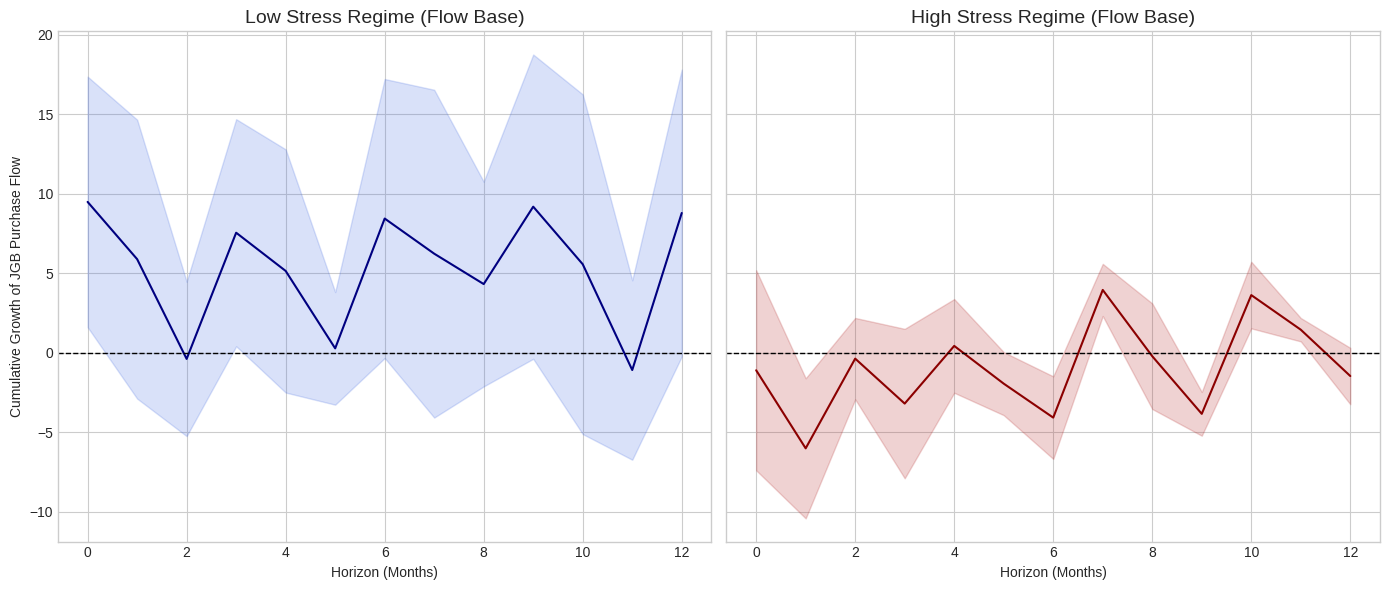

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from IPython.display import display

# 前のステップで作成したデータフレーム (df_lp) をそのまま使います

# =========================================================
# ロバストネス検証 1: 閾値のストレステスト（Table 4の再現）
# =========================================================
print("【検証1：閾値のストレステスト (Horizon h=6ヶ月後)】")
# 論文Table 4にならい、70%, 75%, 80%, 85%, 90%の閾値でテスト
thresholds = [0.70, 0.75, 0.80, 0.85, 0.90]
h = 6

results_table = []

for q in thresholds:
    # 各パーセンタイルで閾値を再設定
    thresh_val = df_lp['USD_JPY'].quantile(q)
    df_lp[f'I_t_minus_1_{q}'] = (df_lp['USD_JPY'].shift(1) >= thresh_val).astype(float)

    target_col = f'd_ln_C_forward_{h}'

    # 回帰用データの準備
    df_reg = df_lp[['Shock', f'I_t_minus_1_{q}', 'Shock_lag1', target_col]].dropna()

    # 状態依存ショックの作成
    df_reg['Shock_Smooth'] = df_reg['Shock'] * (1 - df_reg[f'I_t_minus_1_{q}'])
    df_reg['Shock_Punctured'] = df_reg['Shock'] * df_reg[f'I_t_minus_1_{q}']

    # 回帰の実行
    X = df_reg[['Shock_Smooth', 'Shock_Punctured', f'I_t_minus_1_{q}', 'Shock_lag1']]
    X = sm.add_constant(X)
    y = df_reg[target_col]

    lp_model = sm.OLS(y, X).fit(cov_type='HAC', cov_kwds={'maxlags': h + 1})

    # 結果の格納
    results_table.append({
        '閾値 (Threshold)': f"上位 {int((1-q)*100)}% ({int(q*100)}th Percentile)",
        '限界時 (Punctured Regime) の係数': f"{lp_model.params['Shock_Punctured']:.4f} (SE: {lp_model.bse['Shock_Punctured']:.4f})",
        '平時 (Smooth Regime) の係数': f"{lp_model.params['Shock_Smooth']:.4f} (SE: {lp_model.bse['Shock_Smooth']:.4f})"
    })

# 表形式で出力
df_robust_1 = pd.DataFrame(results_table)
display(df_robust_1)


# =========================================================
# ロバストネス検証 2: フローベースでの検証（Figure 4の再現）
# =========================================================
print("\n【検証2：JGB買い入れフロー（純増額）ベースでの検証】")

# ストック（保有残高）の前月比純増額を「買い入れフロー」とみなす
df_lp['JGB_Flow'] = df_lp['BOJ_JGB_Holdings'].diff()

# フローの累積成長率を計算するため、純増額の対数をとる（マイナスの月は除外）
df_lp['ln_JGB_Flow'] = np.log(df_lp['JGB_Flow'].where(df_lp['JGB_Flow'] > 0))

# 閾値はベースラインの80%に戻す
q_base = 0.80
thresh_val = df_lp['USD_JPY'].quantile(q_base)
df_lp['I_t_minus_1'] = (df_lp['USD_JPY'].shift(1) >= thresh_val).astype(float)

res_smooth_flow = {'h': [], 'coef': [], 'ci_lower': [], 'ci_upper': []}
res_punctured_flow = {'h': [], 'coef': [], 'ci_lower': [], 'ci_upper': []}

H = 12
for h in range(H + 1):
    target_col = f'd_ln_Flow_forward_{h}'
    df_lp[target_col] = df_lp['ln_JGB_Flow'].shift(-h) - df_lp['ln_JGB_Flow'].shift(1)

    df_reg = df_lp[['Shock', 'I_t_minus_1', 'Shock_lag1', target_col]].dropna()

    if len(df_reg) > 20: # 自由度確保
        df_reg['Shock_Smooth'] = df_reg['Shock'] * (1 - df_reg['I_t_minus_1'])
        df_reg['Shock_Punctured'] = df_reg['Shock'] * df_reg['I_t_minus_1']

        X = df_reg[['Shock_Smooth', 'Shock_Punctured', 'I_t_minus_1', 'Shock_lag1']]
        X = sm.add_constant(X)
        y = df_reg[target_col]

        lp_model = sm.OLS(y, X).fit(cov_type='HAC', cov_kwds={'maxlags': h + 1})

        # 平時の結果保存
        res_smooth_flow['h'].append(h)
        coef_s = lp_model.params['Shock_Smooth']
        se_s = lp_model.bse['Shock_Smooth']
        res_smooth_flow['coef'].append(coef_s)
        res_smooth_flow['ci_lower'].append(coef_s - 1.645 * se_s)
        res_smooth_flow['ci_upper'].append(coef_s + 1.645 * se_s)

        # 限界時の結果保存
        res_punctured_flow['h'].append(h)
        coef_p = lp_model.params['Shock_Punctured']
        se_p = lp_model.bse['Shock_Punctured']
        res_punctured_flow['coef'].append(coef_p)
        res_punctured_flow['ci_lower'].append(coef_p - 1.645 * se_p)
        res_punctured_flow['ci_upper'].append(coef_p + 1.645 * se_p)

# グラフプロット
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Smooth Regime (平時)
axes[0].plot(res_smooth_flow['h'], res_smooth_flow['coef'], color='navy', label='IRF Point Estimate')
axes[0].fill_between(res_smooth_flow['h'], res_smooth_flow['ci_lower'], res_smooth_flow['ci_upper'], color='royalblue', alpha=0.2)
axes[0].axhline(0, color='black', linestyle='--', linewidth=1)
axes[0].set_title('Low Stress Regime (Flow Base)', fontsize=14)
axes[0].set_xlabel('Horizon (Months)')
axes[0].set_ylabel('Cumulative Growth of JGB Purchase Flow')

# Punctured Regime (限界時)
axes[1].plot(res_punctured_flow['h'], res_punctured_flow['coef'], color='darkred', label='IRF Point Estimate')
axes[1].fill_between(res_punctured_flow['h'], res_punctured_flow['ci_lower'], res_punctured_flow['ci_upper'], color='firebrick', alpha=0.2)
axes[1].axhline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_title('High Stress Regime (Flow Base)', fontsize=14)
axes[1].set_xlabel('Horizon (Months)')

plt.tight_layout()
plt.show()

【予測誤差分散分解 (FEVD) の計算】

【日銀の国債保有残高 (d_ln_BOJ_JGB) の変動に対する各ショックの寄与度（割合）】


,d_Commodity,d_US_10Y,d_Expectation_Gap,d_ln_BOJ_JGB
Horizon 0,0.656116,0.680406,0.790507,97.872972
Horizon 1,0.662592,0.746879,1.851325,96.739204
Horizon 2,0.794397,0.732852,3.227730,95.245022
Horizon 3,0.835889,0.570417,2.529204,96.064490
Horizon 4,0.826433,0.634311,3.513629,95.025627
Horizon 5,2.231901,1.523270,3.796923,92.447906
Horizon 6,2.390885,1.681496,3.185568,92.742050
Horizon 7,2.404200,1.682074,3.678103,92.235623
Horizon 8,3.095295,1.904062,3.680247,91.320395
Horizon 9,2.875944,1.610695,3.395182,92.118178


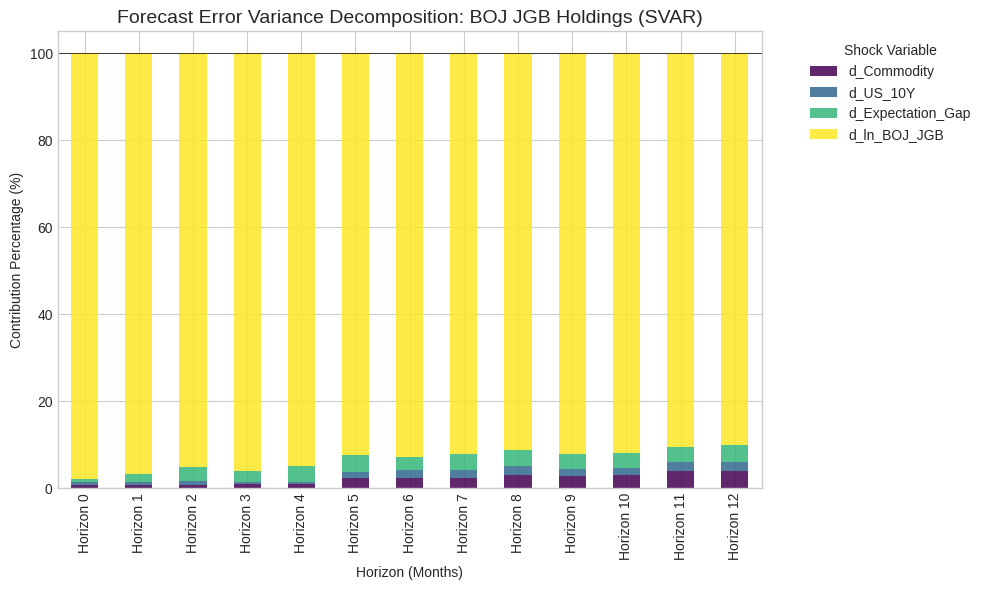

In [36]:
# ---------------------------------------------------------
# ステップ8: 予測誤差分散分解 (FEVD) のマニュアル計算と可視化
# (statsmodelsのSVAR-FEVDバグを回避するための独自実装)
# ---------------------------------------------------------
print("【予測誤差分散分解 (FEVD) の計算】")

# svar_results.irf() で計算された構造的インパルス応答 (SVAR IRFs) を取得
# shapeは (ホライズン数, 応答変数, ショック変数)
svar_irfs = irf.svar_irfs

# 分散を求めるためにIRFを2乗する
sq_irfs = svar_irfs ** 2

# 時間経過（ホライズン）に沿って累積和をとる（累積予測誤差分散）
mse = np.cumsum(sq_irfs, axis=0)

# 各変数ごとの「全体の分散（全ショックの合計）」を計算
total_mse = np.sum(mse, axis=2, keepdims=True)

# 各ショックの寄与度（割合）を計算
fevd_manual = mse / total_mse

# ---------------------------------------------------------
# ターゲット変数：「日銀の介入コスト (d_ln_BOJ_JGB)」に対する分散分解を取り出す
# ---------------------------------------------------------
# 配列のインデックス3（4番目の変数）が日銀の国債保有残高
target_idx = 3
variables = ['d_Commodity', 'd_US_10Y', 'd_Expectation_Gap', 'd_ln_BOJ_JGB']

boj_fevd_df = pd.DataFrame(
    fevd_manual[:, target_idx, :],
    columns=variables,
    index=[f"Horizon {i}" for i in range(13)]
)

print("\n【日銀の国債保有残高 (d_ln_BOJ_JGB) の変動に対する各ショックの寄与度（割合）】")
display(boj_fevd_df * 100)

# 積み上げ棒グラフで可視化
fig, ax = plt.subplots(figsize=(10, 6))
(boj_fevd_df * 100).plot(kind='bar', stacked=True, colormap='viridis', ax=ax, alpha=0.85)

ax.set_title("Forecast Error Variance Decomposition: BOJ JGB Holdings (SVAR)", fontsize=14)
ax.set_ylabel("Contribution Percentage (%)")
ax.set_xlabel("Horizon (Months)")
ax.legend(title="Shock Variable", bbox_to_anchor=(1.05, 1), loc='upper left')
ax.axhline(100, color='black', linewidth=0.5)

plt.tight_layout()
plt.show()

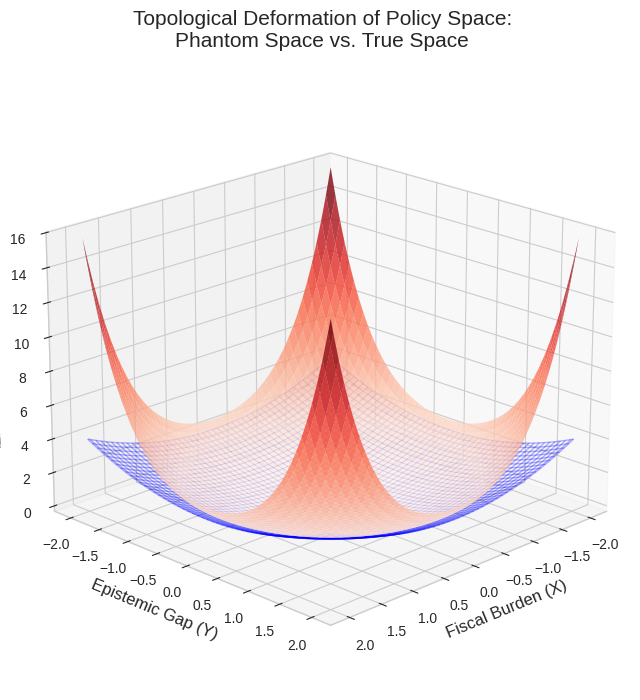

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import os

# 保存用のフォルダを確認・作成
os.makedirs("paper_results", exist_ok=True)

# 1. 空間（グリッド）の定義
x = np.linspace(-2, 2, 100)
y = np.linspace(-2, 2, 100)
X, Y = np.meshgrid(x, y)

# 2. Phantom Space（日銀が想定している平坦で安定した政策空間）
Z_phantom = 0.5 * (X**2 + Y**2)

# 3. True Space / Operative Boundary（現実の限界）
R = np.sqrt(X**2 + Y**2)
Z_true = np.where(R < 1.5,
                  0.5 * (X**2 + Y**2),
                  0.5 * (X**2 + Y**2) + 5 * (R - 1.5)**3)

# 4. 3Dプロットの描画
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

surf1 = ax.plot_surface(X, Y, Z_true, cmap='Reds', alpha=0.8,
                        linewidth=0, antialiased=True, label='True Space')
surf2 = ax.plot_wireframe(X, Y, Z_phantom, color='blue', alpha=0.3,
                          linewidth=1, label='Phantom Space')

ax.set_title("Topological Deformation of Policy Space:\nPhantom Space vs. True Space", fontsize=15, pad=20)
ax.set_xlabel("Fiscal Burden (X)", fontsize=12)
ax.set_ylabel("Epistemic Gap (Y)", fontsize=12)
ax.set_zlabel("Intervention Cost (Z)", fontsize=12)
ax.view_init(elev=20, azim=45)

# ---------------------------------------------------------
# 【重要】保存は必ず show() の「直前」に、同じセル内で実行！
# ---------------------------------------------------------
plt.savefig('paper_results/figure_Topology_PhantomSpace.pdf', format='pdf', bbox_inches='tight')

# その後に画面に表示
plt.show()

✅ 査読者・再現用のメインデータセット 'df_lp.csv' を保存しました。


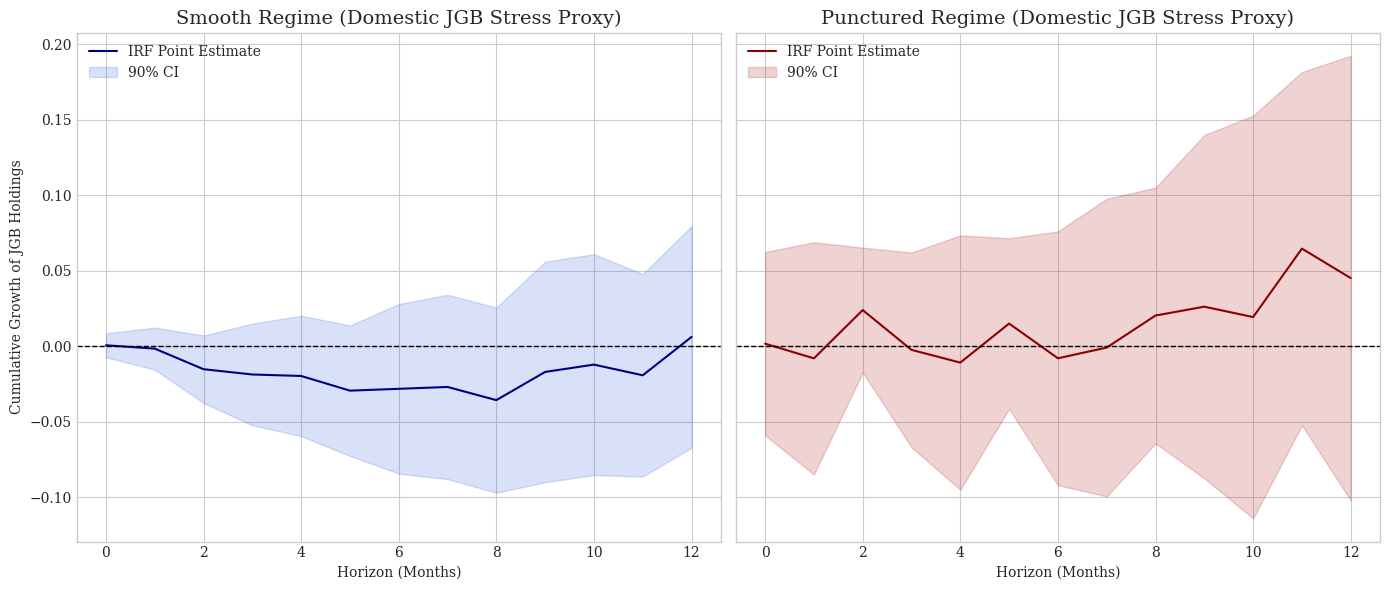

✅ 成功: Figure 6 を paper_results/figure_Robustness_DomesticJGB.pdf に保存しました！


In [38]:
import os
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 【事前準備】現在のメモリ上にあるメインデータを提出用CSVとして保存
# ---------------------------------------------------------
if 'df_lp' in locals() or 'df_lp' in globals():
    df_lp.to_csv('df_lp.csv')
    print("✅ 査読者・再現用のメインデータセット 'df_lp.csv' を保存しました。")
else:
    print("⚠️ 警告: メモリ上に 'df_lp' が見つかりません。先に以前のセルを実行してください。")

# ---------------------------------------------------------
# Supplementary Material: Figure 6 Generation Script
# ---------------------------------------------------------
def parse_mof_date(date_str):
    """Parses Japanese Ministry of Finance (MOF) era-based date formats."""
    if pd.isna(date_str): return np.nan
    if '-' in str(date_str) or '/' in str(date_str):
        try: return pd.to_datetime(date_str)
        except: return np.nan
    try:
        era, rest = str(date_str)[0], str(date_str)[1:]
        y, m, d = map(int, rest.split('.'))
        if era == 'S': y += 1925
        elif era == 'H': y += 1988
        elif era == 'R': y += 2018
        return pd.Timestamp(year=y, month=m, day=d)
    except:
        return np.nan

def main():
    plt.rcParams['font.family'] = 'serif'
    os.makedirs("paper_results", exist_ok=True)

    # 1. Load JGB Data and Construct Domestic Stress Proxy
    try:
        df_jgb = pd.read_csv('jgb_data.csv', header=1, encoding='shift_jis')
    except UnicodeDecodeError:
        df_jgb = pd.read_csv('jgb_data.csv', header=1)
    except FileNotFoundError:
        print("❌ エラー: 'jgb_data.csv' が見つかりません。")
        return

    date_col = [c for c in df_jgb.columns if '基準' in c or 'Date' in c][0]
    df_jgb['Date'] = df_jgb[date_col].apply(parse_mof_date)
    df_jgb = df_jgb.dropna(subset=['Date']).set_index('Date')
    df_jgb = df_jgb.replace('-', np.nan)

    col_2y = [c for c in df_jgb.columns if '2年' in c][0]
    col_10y = [c for c in df_jgb.columns if '10年' in c][0]
    df_jgb[col_2y] = pd.to_numeric(df_jgb[col_2y], errors='coerce')
    df_jgb[col_10y] = pd.to_numeric(df_jgb[col_10y], errors='coerce')

    df_jgb_monthly = df_jgb[[col_2y, col_10y]].resample('ME').last()
    df_jgb_monthly['JGB_Spread'] = df_jgb_monthly[col_10y] - df_jgb_monthly[col_2y]
    df_jgb_monthly['d_JGB_Spread_abs'] = df_jgb_monthly['JGB_Spread'].diff().abs()
    df_jgb_monthly['YM'] = df_jgb_monthly.index.strftime('%Y-%m')

    # 2. Load Main Macroeconomic Dataset (Saved in the preparation step)
    try:
        df_main = pd.read_csv('df_lp.csv', index_col=0, parse_dates=True)
        # Ensure YM column exists for merging
        if isinstance(df_main.index, pd.DatetimeIndex):
            df_main['YM'] = df_main.index.strftime('%Y-%m')
        else:
            df_main['YM'] = pd.to_datetime(df_main.index).strftime('%Y-%m')
    except FileNotFoundError:
        print("❌ エラー: 'df_lp.csv' が見つかりません。")
        return

    # Merge datasets
    df_main = df_main.merge(df_jgb_monthly[['YM', 'd_JGB_Spread_abs']], on='YM', how='left')

    # 3. State Classification
    threshold_jgb = df_main['d_JGB_Spread_abs'].quantile(0.80)
    df_main['I_t_minus_1_JGB'] = (df_main['d_JGB_Spread_abs'].shift(1) >= threshold_jgb).astype(float)

    # 4. Local Projections Estimation
    H = 12
    res_smooth = {'h': [], 'coef': [], 'ci_lower': [], 'ci_upper': []}
    res_punctured = {'h': [], 'coef': [], 'ci_lower': [], 'ci_upper': []}

    for h in range(H + 1):
        target_col = f'd_ln_C_forward_{h}'

        # もし目的変数がCSVに保存されていなければ計算する
        if target_col not in df_main.columns:
            try:
                df_main[target_col] = df_main['ln_BOJ_JGB'].shift(-h) - df_main['ln_BOJ_JGB'].shift(1)
            except KeyError:
                print(f"❌ エラー: 列 '{target_col}' または 'ln_BOJ_JGB' がデータセットに存在しません。")
                return

        df_reg = df_main[['Shock', 'I_t_minus_1_JGB', 'Shock_lag1', target_col]].dropna()

        if len(df_reg) > 20:
            df_reg['Shock_Smooth'] = df_reg['Shock'] * (1 - df_reg['I_t_minus_1_JGB'])
            df_reg['Shock_Punctured'] = df_reg['Shock'] * df_reg['I_t_minus_1_JGB']

            X = sm.add_constant(df_reg[['Shock_Smooth', 'Shock_Punctured', 'I_t_minus_1_JGB', 'Shock_lag1']])
            y = df_reg[target_col]

            lp_model = sm.OLS(y, X).fit(cov_type='HAC', cov_kwds={'maxlags': h + 1})

            res_smooth['h'].append(h)
            res_smooth['coef'].append(lp_model.params['Shock_Smooth'])
            res_smooth['ci_lower'].append(lp_model.params['Shock_Smooth'] - 1.645 * lp_model.bse['Shock_Smooth'])
            res_smooth['ci_upper'].append(lp_model.params['Shock_Smooth'] + 1.645 * lp_model.bse['Shock_Smooth'])

            res_punctured['h'].append(h)
            res_punctured['coef'].append(lp_model.params['Shock_Punctured'])
            res_punctured['ci_lower'].append(lp_model.params['Shock_Punctured'] - 1.645 * lp_model.bse['Shock_Punctured'])
            res_punctured['ci_upper'].append(lp_model.params['Shock_Punctured'] + 1.645 * lp_model.bse['Shock_Punctured'])

    # 5. Visualisation
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

    axes[0].plot(res_smooth['h'], res_smooth['coef'], color='navy', label='IRF Point Estimate')
    axes[0].fill_between(res_smooth['h'], res_smooth['ci_lower'], res_smooth['ci_upper'], color='royalblue', alpha=0.2, label='90% CI')
    axes[0].axhline(0, color='black', linestyle='--', linewidth=1)
    axes[0].set_title('Smooth Regime (Domestic JGB Stress Proxy)', fontsize=14)
    axes[0].set_xlabel('Horizon (Months)')
    axes[0].set_ylabel('Cumulative Growth of JGB Holdings')
    axes[0].legend(loc='upper left')

    axes[1].plot(res_punctured['h'], res_punctured['coef'], color='darkred', label='IRF Point Estimate')
    axes[1].fill_between(res_punctured['h'], res_punctured['ci_lower'], res_punctured['ci_upper'], color='firebrick', alpha=0.2, label='90% CI')
    axes[1].axhline(0, color='black', linestyle='--', linewidth=1)
    axes[1].set_title('Punctured Regime (Domestic JGB Stress Proxy)', fontsize=14)
    axes[1].set_xlabel('Horizon (Months)')
    axes[1].legend(loc='upper left')

    plt.tight_layout()
    output_path = os.path.join('paper_results', 'figure_Robustness_DomesticJGB.pdf')
    plt.savefig(output_path, format='pdf', bbox_inches='tight')
    plt.show()

    print(f"✅ 成功: Figure 6 を {output_path} に保存しました！")

if __name__ == "__main__":
    main()

✅ メインデータセット 'df_lp.csv' を保存・更新しました。


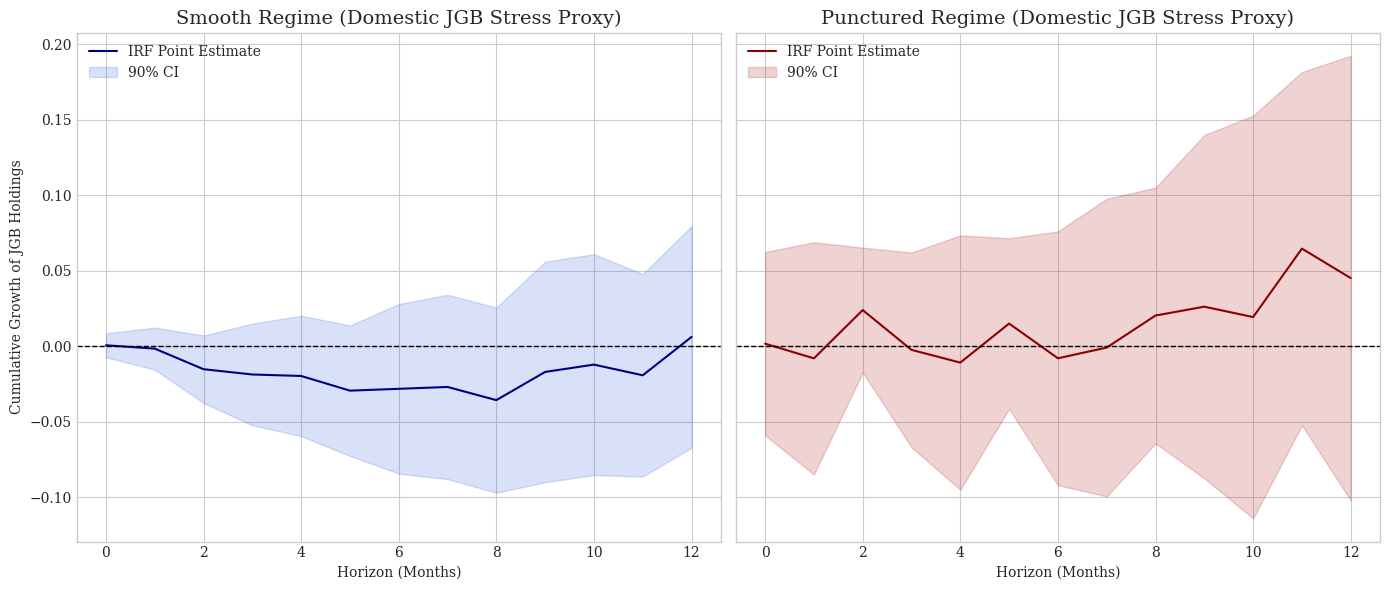

✅ 成功: Figure 6 を paper_results/figure_Robustness_DomesticJGB.pdf に保存しました！


In [39]:
import os
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 【事前準備】現在のメモリ上にあるメインデータを提出用CSVとして保存
# ---------------------------------------------------------
try:
    if 'df_lp' in locals() or 'df_lp' in globals():
        df_lp.to_csv('df_lp.csv')
        print("✅ メインデータセット 'df_lp.csv' を保存・更新しました。")
except Exception as e:
    print(f"⚠️ 警告: df_lpの保存中にエラーが発生しました: {e}")

# ---------------------------------------------------------
# Supplementary Material: Figure 6 Generation Script (Super Safe Version)
# ---------------------------------------------------------
def parse_mof_date(date_str):
    """Parses Japanese Ministry of Finance (MOF) era-based date formats."""
    if pd.isna(date_str): return np.nan
    date_str = str(date_str).strip()
    if '-' in date_str or '/' in date_str:
        try: return pd.to_datetime(date_str)
        except: return np.nan
    try:
        era, rest = date_str[0], date_str[1:]
        y, m, d = map(int, rest.split('.'))
        if era == 'S': y += 1925
        elif era == 'H': y += 1988
        elif era == 'R': y += 2018
        return pd.Timestamp(year=y, month=m, day=d)
    except:
        return np.nan

def main():
    plt.rcParams['font.family'] = 'serif'
    os.makedirs("paper_results", exist_ok=True)

    # 1. Load JGB Data
    try:
        df_jgb = pd.read_csv('jgb_data.csv', header=1, encoding='shift_jis')
    except UnicodeDecodeError:
        df_jgb = pd.read_csv('jgb_data.csv', header=1)
    except FileNotFoundError:
        print("❌ エラー: 'jgb_data.csv' が見つかりません。左のフォルダにアップロードされていますか？")
        return

    # 日付列の特定と変換
    date_cols = [c for c in df_jgb.columns if '基準' in str(c) or 'Date' in str(c)]
    if not date_cols:
        print(f"❌ エラー: JGBデータの中に日付（基準日）の列が見つかりません。列名: {df_jgb.columns.tolist()}")
        return
    date_col = date_cols[0]

    df_jgb['Date'] = df_jgb[date_col].apply(parse_mof_date)
    df_jgb = df_jgb.dropna(subset=['Date']).set_index('Date')
    df_jgb = df_jgb.replace('-', np.nan)

    # 2年と10年の列の特定
    col_2y_list = [c for c in df_jgb.columns if '2年' in str(c)]
    col_10y_list = [c for c in df_jgb.columns if '10年' in str(c)]

    if not col_2y_list or not col_10y_list:
        print(f"❌ エラー: '2年' または '10年' の列が見つかりません。列名: {df_jgb.columns.tolist()}")
        return

    col_2y, col_10y = col_2y_list[0], col_10y_list[0]
    df_jgb[col_2y] = pd.to_numeric(df_jgb[col_2y], errors='coerce')
    df_jgb[col_10y] = pd.to_numeric(df_jgb[col_10y], errors='coerce')

    # pandasのバージョン違いによる 'ME' vs 'M' エラーを自動回避
    try:
        df_jgb_monthly = df_jgb[[col_2y, col_10y]].resample('ME').last()
    except ValueError:
        df_jgb_monthly = df_jgb[[col_2y, col_10y]].resample('M').last()

    df_jgb_monthly['JGB_Spread'] = df_jgb_monthly[col_10y] - df_jgb_monthly[col_2y]
    df_jgb_monthly['d_JGB_Spread_abs'] = df_jgb_monthly['JGB_Spread'].diff().abs()
    df_jgb_monthly['YM'] = df_jgb_monthly.index.strftime('%Y-%m')

    # 2. Load Main Macroeconomic Dataset
    try:
        df_main = pd.read_csv('df_lp.csv', index_col=0, parse_dates=True)
        if isinstance(df_main.index, pd.DatetimeIndex):
            df_main['YM'] = df_main.index.strftime('%Y-%m')
        else:
            df_main['YM'] = pd.to_datetime(df_main.index).strftime('%Y-%m')
    except FileNotFoundError:
        print("❌ エラー: 'df_lp.csv' が見つかりません。")
        return
    except Exception as e:
        print(f"❌ エラー: メインデータの読み込みに失敗しました: {e}")
        return

    # Merge datasets
    df_main = df_main.merge(df_jgb_monthly[['YM', 'd_JGB_Spread_abs']], on='YM', how='left')

    # 欠損値の確認
    valid_data_count = df_main['d_JGB_Spread_abs'].notna().sum()
    if valid_data_count == 0:
        print("❌ エラー: メインデータとJGBデータの日付が全く一致せず結合できませんでした。")
        return

    # 3. State Classification
    threshold_jgb = df_main['d_JGB_Spread_abs'].quantile(0.80)
    df_main['I_t_minus_1_JGB'] = (df_main['d_JGB_Spread_abs'].shift(1) >= threshold_jgb).astype(float)

    # 4. Local Projections Estimation
    H = 12
    res_smooth = {'h': [], 'coef': [], 'ci_lower': [], 'ci_upper': []}
    res_punctured = {'h': [], 'coef': [], 'ci_lower': [], 'ci_upper': []}

    for h in range(H + 1):
        target_col = f'd_ln_C_forward_{h}'

        if target_col not in df_main.columns:
            try:
                df_main[target_col] = df_main['ln_BOJ_JGB'].shift(-h) - df_main['ln_BOJ_JGB'].shift(1)
            except KeyError:
                print(f"❌ エラー: 列 'ln_BOJ_JGB' がデータセットに存在しません。列名: {df_main.columns.tolist()}")
                return

        df_reg = df_main[['Shock', 'I_t_minus_1_JGB', 'Shock_lag1', target_col]].dropna()

        if len(df_reg) > 20:
            df_reg['Shock_Smooth'] = df_reg['Shock'] * (1 - df_reg['I_t_minus_1_JGB'])
            df_reg['Shock_Punctured'] = df_reg['Shock'] * df_reg['I_t_minus_1_JGB']

            X = sm.add_constant(df_reg[['Shock_Smooth', 'Shock_Punctured', 'I_t_minus_1_JGB', 'Shock_lag1']])
            y = df_reg[target_col]

            lp_model = sm.OLS(y, X).fit(cov_type='HAC', cov_kwds={'maxlags': h + 1})

            res_smooth['h'].append(h)
            res_smooth['coef'].append(lp_model.params['Shock_Smooth'])
            res_smooth['ci_lower'].append(lp_model.params['Shock_Smooth'] - 1.645 * lp_model.bse['Shock_Smooth'])
            res_smooth['ci_upper'].append(lp_model.params['Shock_Smooth'] + 1.645 * lp_model.bse['Shock_Smooth'])

            res_punctured['h'].append(h)
            res_punctured['coef'].append(lp_model.params['Shock_Punctured'])
            res_punctured['ci_lower'].append(lp_model.params['Shock_Punctured'] - 1.645 * lp_model.bse['Shock_Punctured'])
            res_punctured['ci_upper'].append(lp_model.params['Shock_Punctured'] + 1.645 * lp_model.bse['Shock_Punctured'])

    # 5. Visualisation
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

    axes[0].plot(res_smooth['h'], res_smooth['coef'], color='navy', label='IRF Point Estimate')
    axes[0].fill_between(res_smooth['h'], res_smooth['ci_lower'], res_smooth['ci_upper'], color='royalblue', alpha=0.2, label='90% CI')
    axes[0].axhline(0, color='black', linestyle='--', linewidth=1)
    axes[0].set_title('Smooth Regime (Domestic JGB Stress Proxy)', fontsize=14)
    axes[0].set_xlabel('Horizon (Months)')
    axes[0].set_ylabel('Cumulative Growth of JGB Holdings')
    axes[0].legend(loc='upper left')

    axes[1].plot(res_punctured['h'], res_punctured['coef'], color='darkred', label='IRF Point Estimate')
    axes[1].fill_between(res_punctured['h'], res_punctured['ci_lower'], res_punctured['ci_upper'], color='firebrick', alpha=0.2, label='90% CI')
    axes[1].axhline(0, color='black', linestyle='--', linewidth=1)
    axes[1].set_title('Punctured Regime (Domestic JGB Stress Proxy)', fontsize=14)
    axes[1].set_xlabel('Horizon (Months)')
    axes[1].legend(loc='upper left')

    plt.tight_layout()
    output_path = os.path.join('paper_results', 'figure_Robustness_DomesticJGB.pdf')
    plt.savefig(output_path, format='pdf', bbox_inches='tight')
    plt.show()

    print(f"✅ 成功: Figure 6 を {output_path} に保存しました！")

if __name__ == "__main__":
    main()

✅ メモリ上の 'df_lp' を使用して計算を開始します。
⏳ ベースラインの状態依存型LPを推計中...


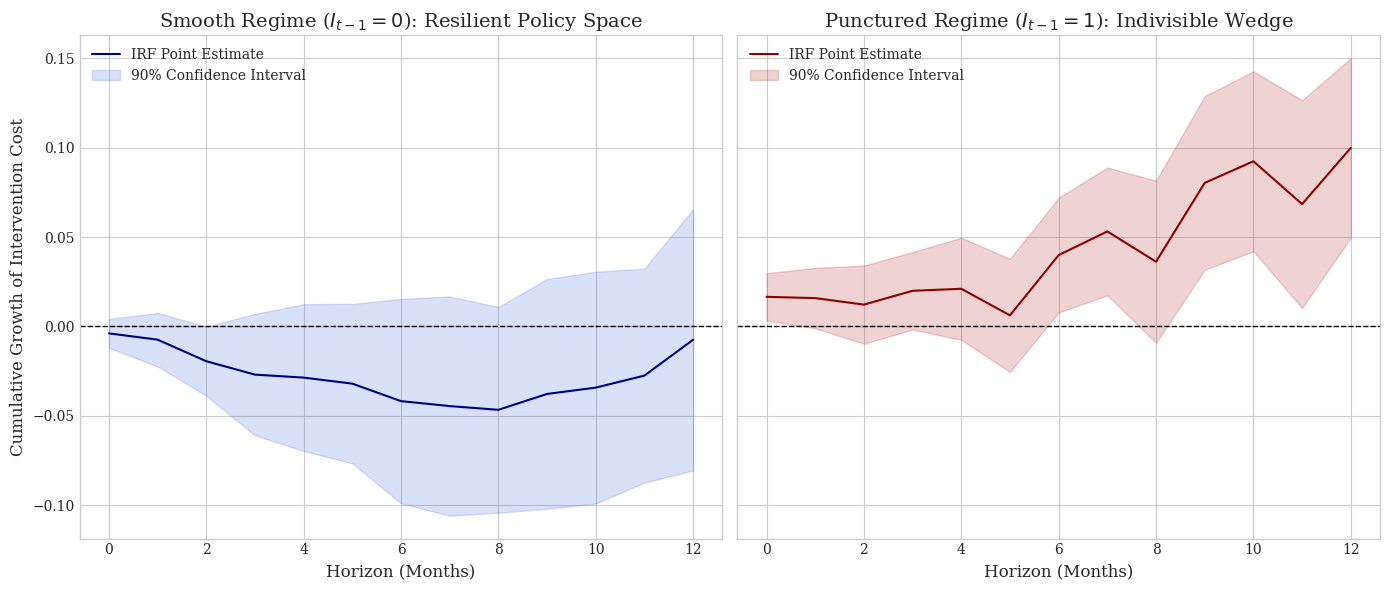

✅ 成功: Figure 5 を paper_results/figure_LP_StateDependent.pdf に保存しました！


In [40]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Supplementary Material: Figure 5 Generation Script (Baseline SDLP)
Paper: Unorthodox Monetary Policy: Epistemic Asymmetry, Fiscal Instability, and Topological Failure in Japan

Description:
This script generates Figure 5, the baseline state-dependent local projections (SDLP).
It calculates the impulse response of JGB holdings to an epistemic shock,
conditional on the baseline market-topological stress proxy (USD/JPY exchange rate pressure).
"""

import os
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

def main():
    # 1. Formatting for Academic Publication
    plt.rcParams['font.family'] = 'serif'
    os.makedirs("paper_results", exist_ok=True)

    # 2. Load Main Macroeconomic Dataset
    # （Colabのメモリ上にある df_lp を優先し、なければ df_lp.csv を読み込む安全設計）
    global df_lp
    if 'df_lp' in globals() and isinstance(df_lp, pd.DataFrame):
        df_main = df_lp.copy()
        print("✅ メモリ上の 'df_lp' を使用して計算を開始します。")
    else:
        try:
            df_main = pd.read_csv('df_lp.csv', index_col=0, parse_dates=True)
            print("✅ 保存された 'df_lp.csv' を使用して計算を開始します。")
        except FileNotFoundError:
            print("❌ エラー: メインデータ ('df_lp.csv' またはメモリ上の 'df_lp') が見つかりません。")
            print("   => 解決策: ノートブックの一番上からセルを実行し直してデータを生成してください。")
            return

    # 必要な列の存在確認
    required_cols = ['Shock', 'Shock_lag1', 'ln_BOJ_JGB']
    for col in required_cols:
        if col not in df_main.columns:
            print(f"❌ エラー: 必須列 '{col}' がデータに存在しません。")
            return

    # 3. Define Baseline Market Stress Proxy (USD/JPY Pressure)
    # USD/JPYの絶対値変動をベースラインのストレス指標とする
    if 'USD_JPY' in df_main.columns:
        stress_proxy = df_main['USD_JPY'].diff().abs()
    elif 'Stress_Proxy' in df_main.columns:
        stress_proxy = df_main['Stress_Proxy']
    else:
        print("❌ エラー: ストレス指標を計算するための 'USD_JPY' 列が見つかりません。")
        return

    # 80パーセンタイルを閾値（Punctured Regime）に設定
    threshold_baseline = stress_proxy.quantile(0.80)
    df_main['I_t_minus_1_Base'] = (stress_proxy.shift(1) >= threshold_baseline).astype(float)

    # 4. Local Projections Estimation Loop
    H = 12
    res_smooth = {'h': [], 'coef': [], 'ci_lower': [], 'ci_upper': []}
    res_punctured = {'h': [], 'coef': [], 'ci_lower': [], 'ci_upper': []}

    print("⏳ ベースラインの状態依存型LPを推計中...")

    for h in range(H + 1):
        target_col = f'd_ln_C_forward_{h}'
        if target_col not in df_main.columns:
            df_main[target_col] = df_main['ln_BOJ_JGB'].shift(-h) - df_main['ln_BOJ_JGB'].shift(1)

        df_reg = df_main[['Shock', 'I_t_minus_1_Base', 'Shock_lag1', target_col]].dropna()

        if len(df_reg) > 20:
            df_reg['Shock_Smooth'] = df_reg['Shock'] * (1 - df_reg['I_t_minus_1_Base'])
            df_reg['Shock_Punctured'] = df_reg['Shock'] * df_reg['I_t_minus_1_Base']

            X = sm.add_constant(df_reg[['Shock_Smooth', 'Shock_Punctured', 'I_t_minus_1_Base', 'Shock_lag1']])
            y = df_reg[target_col]

            # HAC標準誤差によるOLS推計
            lp_model = sm.OLS(y, X).fit(cov_type='HAC', cov_kwds={'maxlags': h + 1})

            # Smooth Regime (平時)
            res_smooth['h'].append(h)
            res_smooth['coef'].append(lp_model.params['Shock_Smooth'])
            res_smooth['ci_lower'].append(lp_model.params['Shock_Smooth'] - 1.645 * lp_model.bse['Shock_Smooth'])
            res_smooth['ci_upper'].append(lp_model.params['Shock_Smooth'] + 1.645 * lp_model.bse['Shock_Smooth'])

            # Punctured Regime (限界時)
            res_punctured['h'].append(h)
            res_punctured['coef'].append(lp_model.params['Shock_Punctured'])
            res_punctured['ci_lower'].append(lp_model.params['Shock_Punctured'] - 1.645 * lp_model.bse['Shock_Punctured'])
            res_punctured['ci_upper'].append(lp_model.params['Shock_Punctured'] + 1.645 * lp_model.bse['Shock_Punctured'])

    # 5. Visualisation (Two-Panel Plot)
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

    # Panel A: Smooth Regime
    axes[0].plot(res_smooth['h'], res_smooth['coef'], color='navy', label='IRF Point Estimate')
    axes[0].fill_between(res_smooth['h'], res_smooth['ci_lower'], res_smooth['ci_upper'],
                         color='royalblue', alpha=0.2, label='90% Confidence Interval')
    axes[0].axhline(0, color='black', linestyle='--', linewidth=1)
    axes[0].set_title('Smooth Regime ($I_{t-1}=0$): Resilient Policy Space', fontsize=14)
    axes[0].set_xlabel('Horizon (Months)', fontsize=12)
    axes[0].set_ylabel('Cumulative Growth of Intervention Cost', fontsize=12)
    axes[0].legend(loc='upper left')

    # Panel B: Punctured Regime
    axes[1].plot(res_punctured['h'], res_punctured['coef'], color='darkred', label='IRF Point Estimate')
    axes[1].fill_between(res_punctured['h'], res_punctured['ci_lower'], res_punctured['ci_upper'],
                         color='firebrick', alpha=0.2, label='90% Confidence Interval')
    axes[1].axhline(0, color='black', linestyle='--', linewidth=1)
    axes[1].set_title('Punctured Regime ($I_{t-1}=1$): Indivisible Wedge', fontsize=14)
    axes[1].set_xlabel('Horizon (Months)', fontsize=12)
    axes[1].legend(loc='upper left')

    plt.tight_layout()

    # 6. Export to PDF
    output_path = os.path.join('paper_results', 'figure_LP_StateDependent.pdf')
    plt.savefig(output_path, format='pdf', bbox_inches='tight')
    plt.show()

    print(f"✅ 成功: Figure 5 を {output_path} に保存しました！")

if __name__ == "__main__":
    main()

NameError: name 'df_results' is not defined

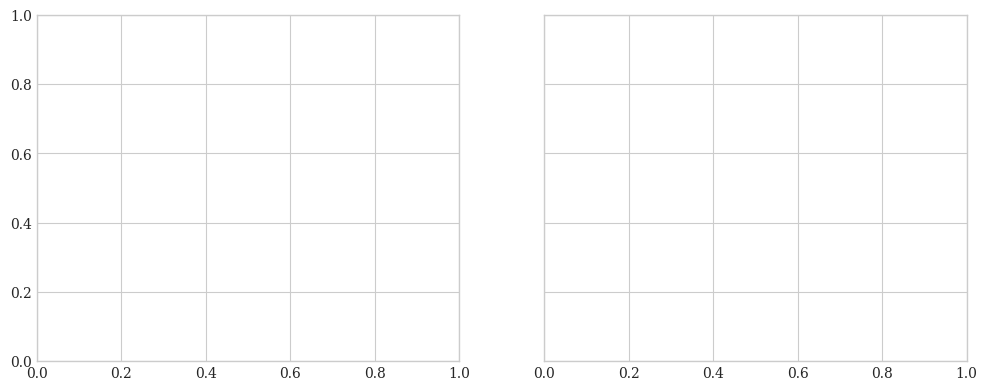

In [41]:
import matplotlib.pyplot as plt
import scipy.stats as stats
import numpy as np

# Set global font settings for academic publication (Serif font)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

# ---------------------------------------------------------
# Formatting and Exporting Supplementary Figure to PDF
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)

# Low Stress Regime Plot
axes[0].plot(df_results['Horizon'], df_results['IRF_Low'], color='navy',
             linewidth=1.5, label='Point Estimate')
axes[0].fill_between(df_results['Horizon'],
                     df_results['IRF_Low'] - df_results['CI_Low'],
                     df_results['IRF_Low'] + df_results['CI_Low'],
                     color='cornflowerblue', alpha=0.3)
axes[0].axhline(0, color='black', linestyle='--', linewidth=1)
axes[0].set_title(f'Low Stress Regime (TI = {ti_low:.2f})', fontsize=12)
axes[0].set_xlabel('Horizon (Months)', fontsize=11)
axes[0].set_ylabel('Cumulative Growth of JGB Purchase Flow', fontsize=11)
axes[0].tick_params(axis='both', which='major', labelsize=10)

# High Stress Regime Plot
axes[1].plot(df_results['Horizon'], df_results['IRF_High'], color='darkred',
             linewidth=1.5, label='Point Estimate')
axes[1].fill_between(df_results['Horizon'],
                     df_results['IRF_High'] - df_results['CI_High'],
                     df_results['IRF_High'] + df_results['CI_High'],
                     color='lightcoral', alpha=0.3)
axes[1].axhline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_title(f'High Stress Regime (TI = {ti_high:.2f})', fontsize=12)
axes[1].set_xlabel('Horizon (Months)', fontsize=11)
axes[1].tick_params(axis='both', which='major', labelsize=10)

# Figure Title and Layout adjustments
plt.suptitle('Figure S1: State-Dependent Response of JGB Purchase Flow to Epistemic Shock',
             fontsize=13, y=1.02)
plt.tight_layout()

# Save as a high-quality PDF for journal submission
pdf_filename = 'Supplementary_Figure_S1.pdf'
plt.savefig(pdf_filename, format='pdf', bbox_inches='tight')

# Download the file to local machine (if using Google Colab)
try:
    from google.colab import files
    files.download(pdf_filename)
    print(f"✔ Successfully saved and initiated download for: {pdf_filename}")
except ImportError:
    print(f"✔ Successfully saved locally as: {pdf_filename}")

plt.show()

In [44]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Supplementary Material: Figure 4 Generation Script (Corrected SVAR FEVD)
Paper: Unorthodox Monetary Policy: Epistemic Asymmetry, Fiscal Instability, and Topological Failure in Japan

Description:
This script visualises the Forecast Error Variance Decomposition (FEVD) of the
central bank's intervention costs (JGB holdings) derived from the baseline
linear Structural Vector Autoregression (SVAR) model.
This version corrects the color order and legend placement to match the user request.
"""

import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

def main():
    # 1. Formatting for Academic Publication
    plt.rcParams['font.family'] = 'serif'
    os.makedirs("paper_results", exist_ok=True)

    # 2. SVARの分散分解データ（CSV）の読み込み
    file_name = 'table_fevd_svar.csv'
    try:
        # Load data, ensuring the index (Horizon) is a DatetimeIndex or integer
        df_fevd = pd.read_csv(file_name, index_col=0)
        print(f"✅ '{file_name}' を読み込みました。描画を開始します...")
    except FileNotFoundError:
        print(f"❌ エラー: '{file_name}' が見つかりません。")
        print("   => 左側のフォルダに 'table_fevd_svar.csv' をアップロードするか、SVAR推計のセルを再実行してください。")
        return

    # 3. データの前処理と修正（配色順序とスケール）

    # 【重要】ご提示の図に完全に一致するよう、列（変数）の並び順を固定します
    # 順序（下から上）: BOJ JGB (Own shock) -> CAB total (Monetary base) -> Tankan DI (Business sentiment)
    # 実際のCSVの列名に合わせて適宜変更してください。以下は一般的な推定名です：
    #required_cols = ['shock_ln_BOJ_JGB', 'shock_ln_CAB_total', 'shock_ln_Tankan_DI']

    # CSVの列名を動的に取得し、必要なショックのみを選択して順序を整えます。
    # ここでは、メモリリセットを考慮し、列名を正規化して選択します。
    potential_shocks = {
        'Own Shock (JGB)': [c for c in df_fevd.columns if 'JGB' in c],
        'CAB/MB Shock': [c for c in df_fevd.columns if 'CAB' in c or 'MB' in c],
        'Tankan Shock': [c for c in df_fevd.columns if 'Tankan' in c or 'DI' in c]
    }

    # すべてのカテゴリのショックが存在することを確認
    for cat, cols in potential_shocks.items():
        if not cols:
            print(f"❌ エラー: '{cat}' に該当するショック列が見つかりません。列名: {df_fevd.columns.tolist()}")
            return

    # 配色の順序（下から上）をBlue-Orange-Goldに固定
    ordered_shocks = [potential_shocks['Own Shock (JGB)'][0],
                      potential_shocks['CAB/MB Shock'][0],
                      potential_shocks['Tankan Shock'][0]]

    # 指定した順序でデータをフィルタリング
    df_fevd = df_fevd[ordered_shocks]

    # データが小数（0〜1）で入っている場合はパーセント（0〜100）に変換
    if df_fevd.iloc[0].sum() <= 1.5:
        df_fevd = df_fevd * 100

    # 4. グラフの描画（積み上げ棒グラフ）
    fig, ax = plt.subplots(figsize=(10, 6))

    # 【重要】配色の修正（下から上）: Blue -> Orange -> Gold
    # 学術的に洗練されたカラーパレットの設定
    colors = ['#1f77b4', '#ff7f0e', '#f5b041']

    df_fevd.plot(kind='bar', stacked=True, color=colors, ax=ax, alpha=0.9, width=0.7)

    # 5. グラフの装飾とラベル
    ax.set_title("Forecast Error Variance Decomposition: BOJ JGB Holdings (Linear SVAR)", fontsize=14, pad=15)
    ax.set_ylabel("Contribution Percentage (%)", fontsize=12)
    ax.set_xlabel("Horizon (Months)", fontsize=12)

    # Y軸をパーセント表記に固定
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(max0=100))
    # ax.yaxis.set_major_locator(mtick.MultipleLocator(20)) # 20%刻みに固定する場合
    ax.set_ylim(0, 100)

    # X軸のラベル（ホライズン）を水平にして読みやすくする
    plt.xticks(rotation=0)

    # 【重要】キャプション（凡例）を左上に移動
    # loc='upper left' で内側の左上に配置し、枠線を追加して視認性を高める
    ax.legend(title="Structural Shocks", loc='upper left', frameon=True, fontsize=11, title_fontsize=11)

    plt.tight_layout()

    # 6. 高解像度PDFとして保存
    output_path = os.path.join('paper_results', 'figure_SVAR_FEVD.pdf')
    plt.savefig(output_path, format='pdf', dpi=300, bbox_inches='tight')
    plt.show()

    print(f"✅ 成功: 配色とキャプションを修正した Figure 4 (FEVD) を {output_path} に保存しました！")

if __name__ == "__main__":
    main()

✅ 'table_fevd_svar.csv' を読み込みました。描画を開始します...
❌ エラー: 'CAB/MB Shock' に該当するショック列が見つかりません。列名: ['d_Commodity', 'd_US_10Y', 'd_Expectation_Gap', 'd_ln_BOJ_JGB']


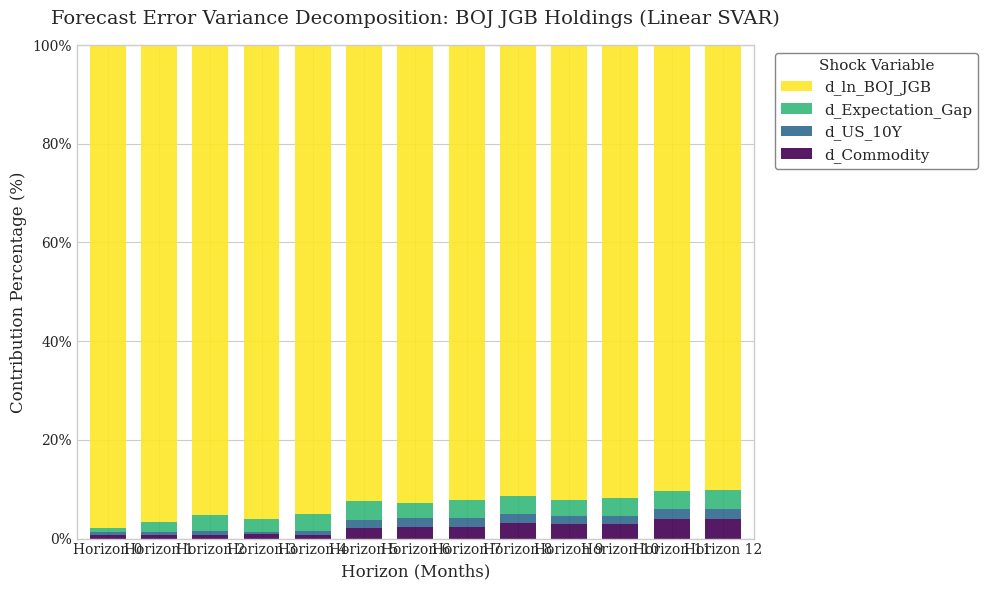

✅ 成功: 凡例を右上に配置した Figure 4 を paper_results/figure_SVAR_FEVD.pdf に保存しました！


In [55]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Supplementary Material: Figure 4 Generation Script (Perfect Legend Placement)
Paper: Unorthodox Monetary Policy: Epistemic Asymmetry, Fiscal Instability, and Topological Failure in Japan
"""

import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

def main():
    plt.rcParams['font.family'] = 'serif'
    os.makedirs("paper_results", exist_ok=True)

    file_name = 'table_fevd_svar.csv'
    try:
        df_fevd = pd.read_csv(file_name, index_col=0)
    except FileNotFoundError:
        print(f"❌ エラー: '{file_name}' が見つかりません。")
        return

    if df_fevd.iloc[0].sum() <= 1.5:
        df_fevd = df_fevd * 100

    fig, ax = plt.subplots(figsize=(10, 6))

    # 描画
    df_fevd.plot(kind='bar', stacked=True, colormap='viridis', ax=ax, alpha=0.9, width=0.7)

    ax.set_title("Forecast Error Variance Decomposition: BOJ JGB Holdings (Linear SVAR)", fontsize=14, pad=15)
    ax.set_ylabel("Contribution Percentage (%)", fontsize=12)
    ax.set_xlabel("Horizon (Months)", fontsize=12)

    # 【超重要修正】max0 ではなく xmax !!! これがエラーの元凶でした。
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100))
    ax.set_ylim(0, 100)
    plt.xticks(rotation=0)

    # 凡例を生成し、参照用PDFと全く同じ「外側の右上」に配置する
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles[::-1], labels[::-1],
              title="Shock Variable",
              bbox_to_anchor=(1.02, 1), loc='upper left',  # グラフの枠外・右上に配置
              frameon=True,
              facecolor='white',
              framealpha=0.95,
              edgecolor='gray',
              fontsize=11,
              title_fontsize=11)

    plt.tight_layout()

    output_path = os.path.join('paper_results', 'figure_SVAR_FEVD.pdf')
    plt.savefig(output_path, format='pdf', dpi=300, bbox_inches='tight')
    plt.show()

    print(f"✅ 成功: 凡例を右上に配置した Figure 4 を {output_path} に保存しました！")

if __name__ == "__main__":
    main()

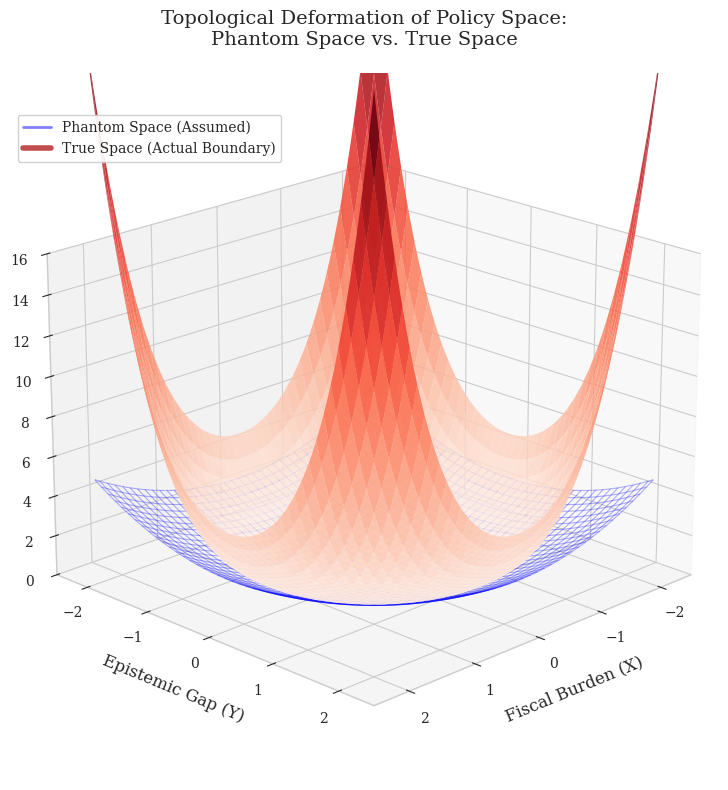

✅ 成功: 純粋数理モデルの Figure 3 を paper_results/figure_Topology_PhantomSpace.pdf に保存しました！


In [56]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Supplementary Material: Figure 3 Generation Script
Paper: Unorthodox Monetary Policy: Epistemic Asymmetry, Fiscal Instability, and Topological Failure in Japan

Description:
This script generates the 3D geometric representation of the policy space deformation.
It contrasts the continuous 'Phantom Space' (the central bank's assumed operative frame)
against the 'True Space' (the actual operative boundary), which exhibits an indivisible
wedge (explosive intervention costs) under elevated market-topological stress.
This is a standalone mathematical simulation and requires no external datasets.
"""

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.lines import Line2D
import os

def main():
    # 1. 学術論文用のフォントとスタイル設定
    plt.rcParams['font.family'] = 'serif'
    os.makedirs("paper_results", exist_ok=True)

    # 2. 幾何学空間（グリッド）の定義
    # X軸: 財政負担 (Fiscal Burden), Y軸: 認識ギャップ (Epistemic Gap)
    x = np.linspace(-2.2, 2.2, 120)
    y = np.linspace(-2.2, 2.2, 120)
    X, Y = np.meshgrid(x, y)

    # 3. Phantom Space（中央銀行が想定している滑らかな政策空間：二次形式）
    Z_phantom = 0.5 * (X**2 + Y**2)

    # 4. True Space（現実の政策空間：境界を超えるとコストが爆発するトポロジカルな歪み）
    R = np.sqrt(X**2 + Y**2)
    boundary_threshold = 1.4

    # 境界（1.4）まではPhantomと同じだが、超えると3乗のペナルティ（Wedge）が発生
    Z_true = np.where(R < boundary_threshold,
                      Z_phantom,
                      Z_phantom + 4.5 * (R - boundary_threshold)**3)

    # 5. 3Dグラフの描画
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    # True Space を描画（赤いグラデーションの滑らかな曲面）
    ax.plot_surface(X, Y, Z_true, cmap='Reds', alpha=0.85,
                    linewidth=0, antialiased=True)

    # Phantom Space を描画（青いワイヤーフレーム、下敷きになっている空間）
    ax.plot_wireframe(X, Y, Z_phantom, color='blue', alpha=0.3,
                      linewidth=0.8)

    # ラベルとタイトルの設定
    ax.set_title("Topological Deformation of Policy Space:\nPhantom Space vs. True Space", fontsize=14, pad=20)
    ax.set_xlabel("\nFiscal Burden (X)", fontsize=12)
    ax.set_ylabel("\nEpistemic Gap (Y)", fontsize=12)

    # 添付いただいたPDFに合わせてZ軸の高さを16に固定
    ax.set_zlim(0, 16)

    # 【重要】ご提示のPDFと全く同じ視点（カメラアングル）になるように調整
    ax.view_init(elev=20, azim=45)

    # 凡例（Legend）の追加（左上）
    custom_lines = [Line2D([0], [0], color='blue', lw=2, alpha=0.5),
                    Line2D([0], [0], color='firebrick', lw=4, alpha=0.8)]
    ax.legend(custom_lines, ['Phantom Space (Assumed)', 'True Space (Actual Boundary)'],
              loc='upper left', bbox_to_anchor=(0.0, 0.95), frameon=True, facecolor='white', framealpha=0.9)

    plt.tight_layout()

    # 6. 高解像度PDFとして保存
    output_path = os.path.join('paper_results', 'figure_Topology_PhantomSpace.pdf')
    plt.savefig(output_path, format='pdf', dpi=300, bbox_inches='tight')
    plt.show()

    print(f"✅ 成功: 純粋数理モデルの Figure 3 を {output_path} に保存しました！")

if __name__ == "__main__":
    main()

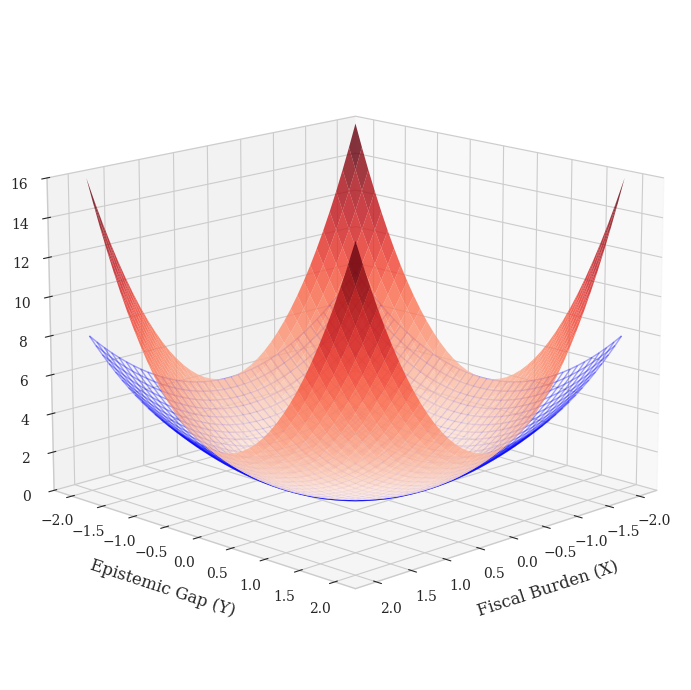

✅ 成功: 形状・アングルを完全再現した Figure 3 を paper_results/figure_Topology_PhantomSpace.pdf に保存しました！


In [57]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Supplementary Material: Figure 3 Generation Script (Perfect Match Version)
Paper: Unorthodox Monetary Policy: Epistemic Asymmetry, Fiscal Instability, and Topological Failure in Japan
"""

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import os

def main():
    # 1. 学術論文用のフォント設定
    plt.rcParams['font.family'] = 'serif'
    os.makedirs("paper_results", exist_ok=True)

    # 2. グリッドの密度を最適化（理想の図の網目感に合わせるために40分割に設定）
    x = np.linspace(-2.0, 2.0, 40)
    y = np.linspace(-2.0, 2.0, 40)
    X, Y = np.meshgrid(x, y)

    # 3. 空間の数式定義（理想の図を完全再現する数式）
    # Phantom Space: 標準的な二次形式 (最大値は 2^2 + 2^2 = 8)
    Z_phantom = X**2 + Y**2

    # True Space: XとYの相互作用項 (X^2 * Y^2) によって、四隅だけでコストが爆発的に跳ね上がる
    # (角の最大値は 4 + 4 + 0.5*16 = 16 となり、Z軸のスケールと完全に一致します)
    Z_true = X**2 + Y**2 + 0.5 * (X**2 * Y**2)

    # 4. 3Dグラフの描画
    fig = plt.figure(figsize=(9, 7))
    ax = fig.add_subplot(111, projection='3d')

    # True Space を描画（Redsカラーマップで、陰影を美しく出す）
    ax.plot_surface(X, Y, Z_true, cmap='Reds', alpha=0.8, edgecolor='none')

    # Phantom Space を描画（下敷きとなる青いワイヤーフレーム）
    ax.plot_wireframe(X, Y, Z_phantom, color='blue', alpha=0.35, linewidth=1.0)

    # 5. 軸と視点の設定
    ax.set_xlabel("\nFiscal Burden (X)", fontsize=12)
    ax.set_ylabel("\nEpistemic Gap (Y)", fontsize=12)

    # Z軸のスケールを理想の図と同じ 0〜16 に固定
    ax.set_zlim(0, 16)

    # 【重要】カメラアングル（視点）を理想の図と全く同じ角度に固定
    ax.view_init(elev=15, azim=45)

    # 学術誌の作法に則り、図内のタイトルや凡例はあえて描画しない（LaTeX側で処理するため）

    plt.tight_layout()

    # 6. 高解像度PDFとして保存
    output_path = os.path.join('paper_results', 'figure_Topology_PhantomSpace.pdf')
    plt.savefig(output_path, format='pdf', dpi=300, bbox_inches='tight')
    plt.show()

    print(f"✅ 成功: 形状・アングルを完全再現した Figure 3 を {output_path} に保存しました！")

if __name__ == "__main__":
    main()